In [20]:
%pip install xlrd

################ Load data ready for nested logit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data_with_IV.csv')
charging_df = pd.read_csv('Data Cleaning/charging_station_data.csv')
global_bev = pd.read_excel('C:/Users/Lenovo/Desktop/Dissertaion/China Data/Other/global_bev.xls')
global_phev = pd.read_excel('C:/Users/Lenovo/Desktop/Dissertaion/China Data/Other/global_phev.xls')

Note: you may need to restart the kernel to use updated packages.


In [13]:
df['fuel_type'].unique

<bound method Series.unique of 0         BEV
1        PHEV
2        PHEV
3         BEV
4         BEV
         ... 
79285    PHEV
79286     Gas
79287     Gas
79288     Gas
79289     Gas
Name: fuel_type, Length: 79290, dtype: object>

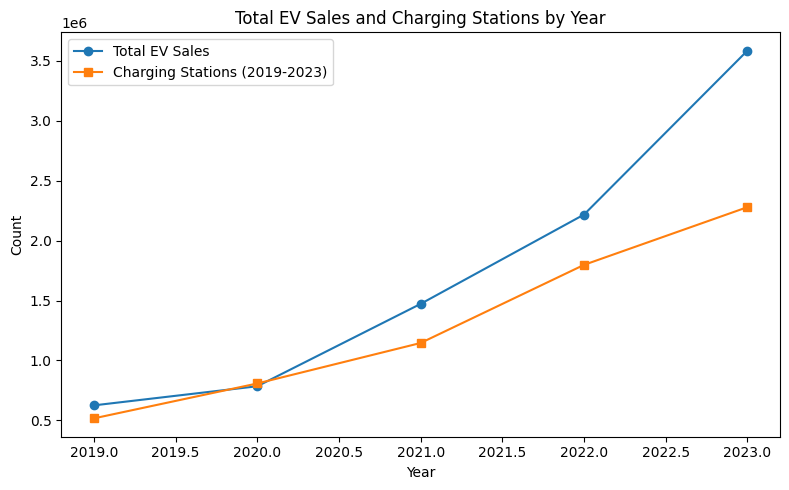

In [15]:
################ EV stock v.s. Charging stations
# Group by year and sum EV sales and charging stations
ev_sales_sum = (
    df[df['fuel_type'].isin(['BEV', 'PHEV'])]  # filter for BEV or PHEV
    .groupby('year')['sales']
    .sum()
)
charging_stock_sum = charging_df.groupby('year')['公共充电桩保有量（台）'].sum()

# Filter charging stations for 2019-2023
charging_stock_sum = charging_stock_sum.loc[(charging_stock_sum.index >= 2019) & (charging_stock_sum.index <= 2023)]

# Plot both on the same figure
plt.figure(figsize=(8, 5))
plt.plot(ev_sales_sum.index, ev_sales_sum.values, label='Total EV Sales', marker='o')
plt.plot(charging_stock_sum.index, charging_stock_sum.values, label='Charging Stations (2019-2023)', marker='s')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Total EV Sales and Charging Stations by Year')
plt.legend()
plt.tight_layout()
plt.show()


year
2019    16381072
2020    14903937
2021    14903626
2022    13128045
2023    13440242
Name: sales, dtype: int64